# Vector Semantics – Part 1

# What is Vector semantic ?

Vector semantics represents a word in multi-dimensional vector space. Vector model is also called Embeddings, due to the fact that word is embedded in a particular vector space. Vector model offers many advantages in NLP. For example, in sentimental analysis, it sets up a boundary class and predicts if the sentiment is positive or negative (a binomial classification). Another key practical advantage with vector semantics is that it can learn automatically from text without complex labeling or supervision. As a result of these advantages, the vector semantics has become a de-facto standard for NLP applications such as Sentiment Analysis, Named Entity Recognition (NER), topic modeling, and so on.

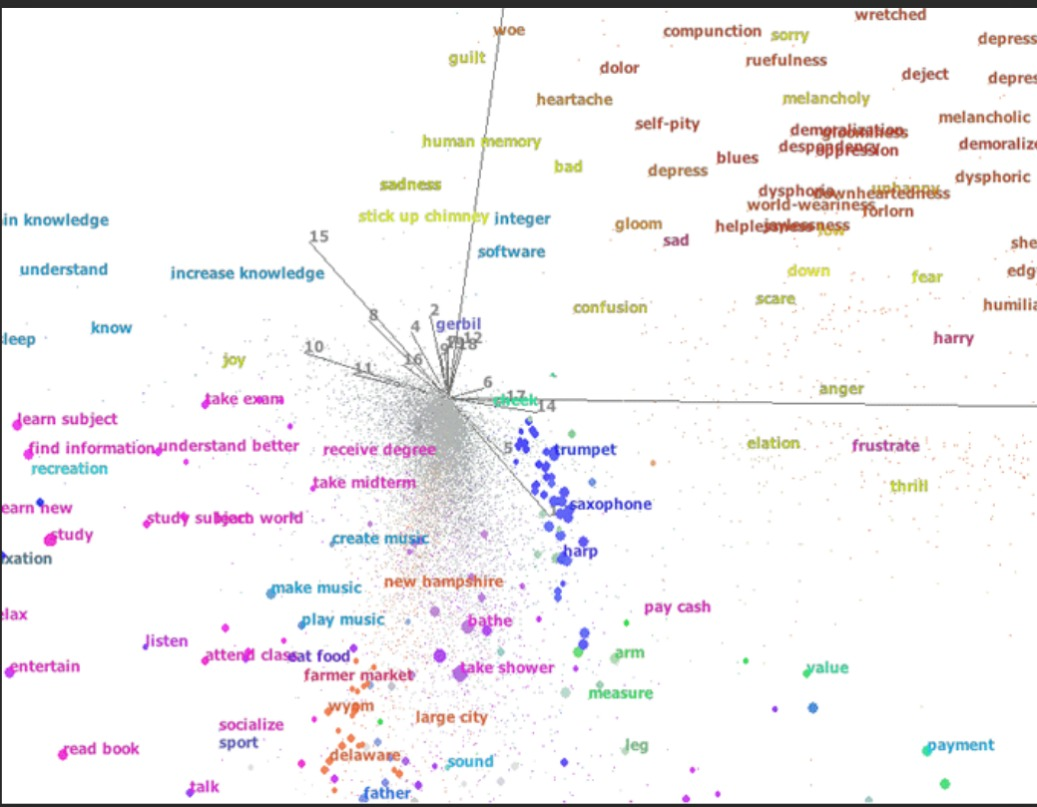

# What is Embedding?

Embeddings in NLP is a technique where individual words are represented as real-valued vectors in a lower-dimensional space and captures inter-word semantics.


In this notebook, We going to intreduce three techniques for embedding. These techniques will be used for a machine learning models such as SVM, Random forest, ... ect.

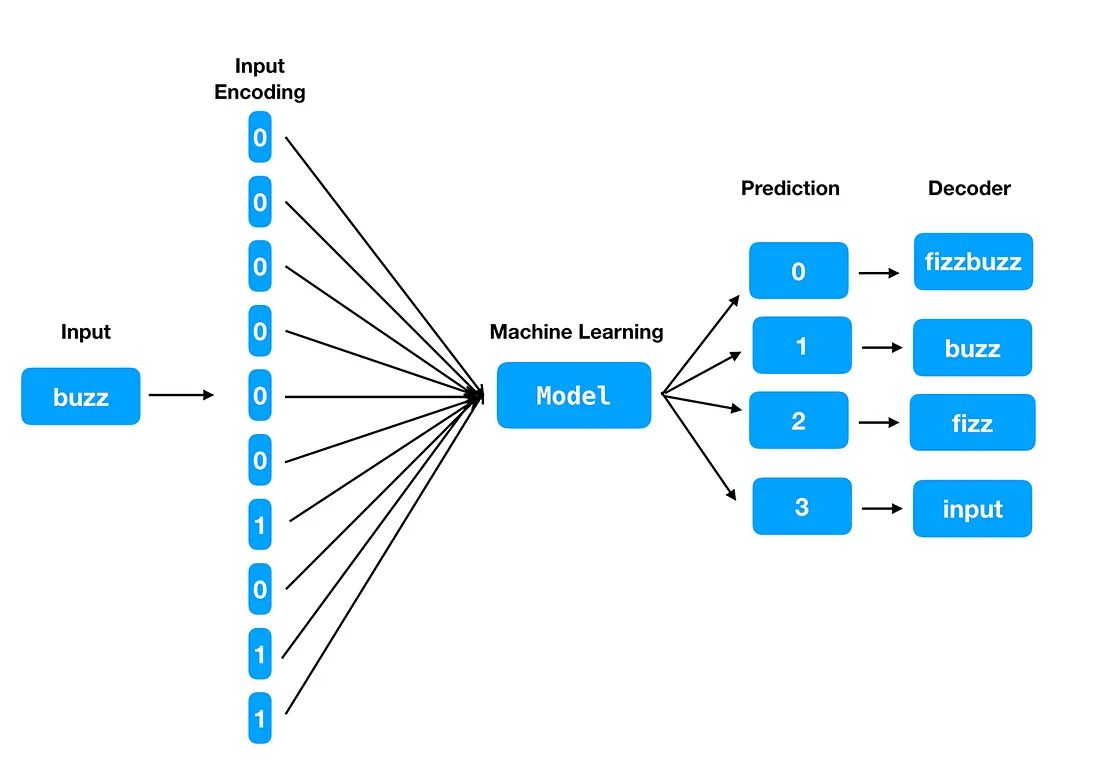

# 1- Term-Document Matrix

In natural language processing, we see many methods of representing text data. Term document matrix is also a method for representing the text data. In this method, the text data is represented in the form of a matrix. The rows of the matrix represent the sentences from the data which needs to be analyzed and the columns of the matrix represent the word. The dice under the matrix represent the number of occurrences of the words. Let’s understand it with an example.

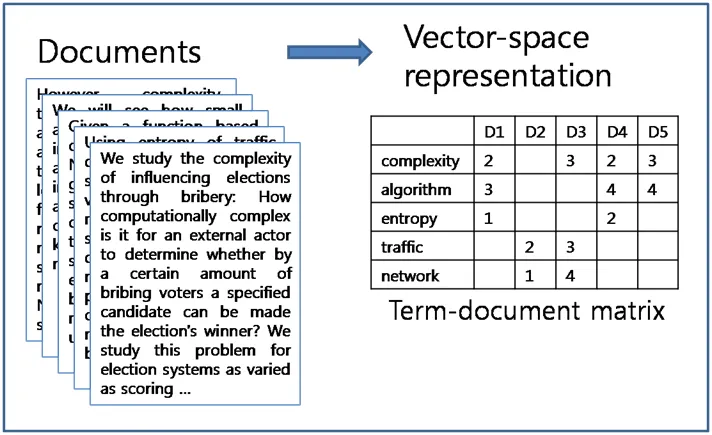

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

sentence1 = "I love football"
sentence2 = "Messi is a great football player"
sentence3 = "Messi has won seven Ballon d’Or awards "

docs = [sentence1, sentence2, sentence3]
print(docs)

['I love football', 'Messi is a great football player', 'Messi has won seven Ballon d’Or awards ']


In [2]:
 # Fit and transform the documents into numerical vectors
vec = CountVectorizer()
X = vec.fit_transform(docs)

In [3]:
df = pd.DataFrame(X.toarray(), columns = vec.get_feature_names_out())
df.head()

,awards,ballon,football,great,has,is,love,messi,or,player,seven,won
0,0,0,1,0,0,0,1,0,0,0,0,0
1,0,0,1,1,0,1,0,1,0,1,0,0
2,1,1,0,0,1,0,0,1,1,0,1,1


# 2- Cosine similarity

In NLP, Cosine similarity is a metric used to measure how similar the documents are irrespective of their size.

Let’s compute the Cosine similarity between two text document and observe how it works.

The common way to compute the Cosine similarity is to first we need to count the word occurrence in each document. To count the word occurrence in each document, we can use CountVectorizer or TfidfVectorizer functions that are provided by Scikit-Learn library.

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
# Sample text data (replace with your own documents)

doc_1 = "Data is the oil of the digital economy"
doc_2 = "Data is a new oil"

data = [doc_1, doc_2]

In [6]:
count_vectorizer = CountVectorizer() # Create a CountVectorizer instance
vector_matrix = count_vectorizer.fit_transform(data) # Fit and transform the documents into numerical vectors

In [7]:
# Get the feature names (words)
tokens = count_vectorizer.get_feature_names_out()
tokens

array(['data', 'digital', 'economy', 'is', 'new', 'of', 'oil', 'the'],
      dtype=object)

In [8]:
df = pd.DataFrame(data=vector_matrix.toarray(), index=data, columns=tokens)
df.head()

,data,digital,economy,is,new,of,oil,the
Data is the oil of the digital economy,1,1,1,1,0,1,1,2
Data is a new oil,1,0,0,1,1,0,1,0


In [9]:
# Calculate the cosine similarity between the documents
cosine_similarity_matrix = cosine_similarity(vector_matrix)
df_cosine = pd.DataFrame(data=cosine_similarity_matrix, index=data, columns=data)

In [10]:
# Print the cosine similarity matrix
df_cosine

,Data is the oil of the digital economy,Data is a new oil
Data is the oil of the digital economy,1.000000,0.474342
Data is a new oil,0.474342,1.000000


# 3- TF-IDF

TF-IDF stands for term frequency-inverse document frequency and it is a measure, used in the fields of information retrieval (IR) and machine learning, that can quantify the importance or relevance of string representations (words, phrases, lemmas, etc)  in a document amongst a collection of documents (also known as a corpus).

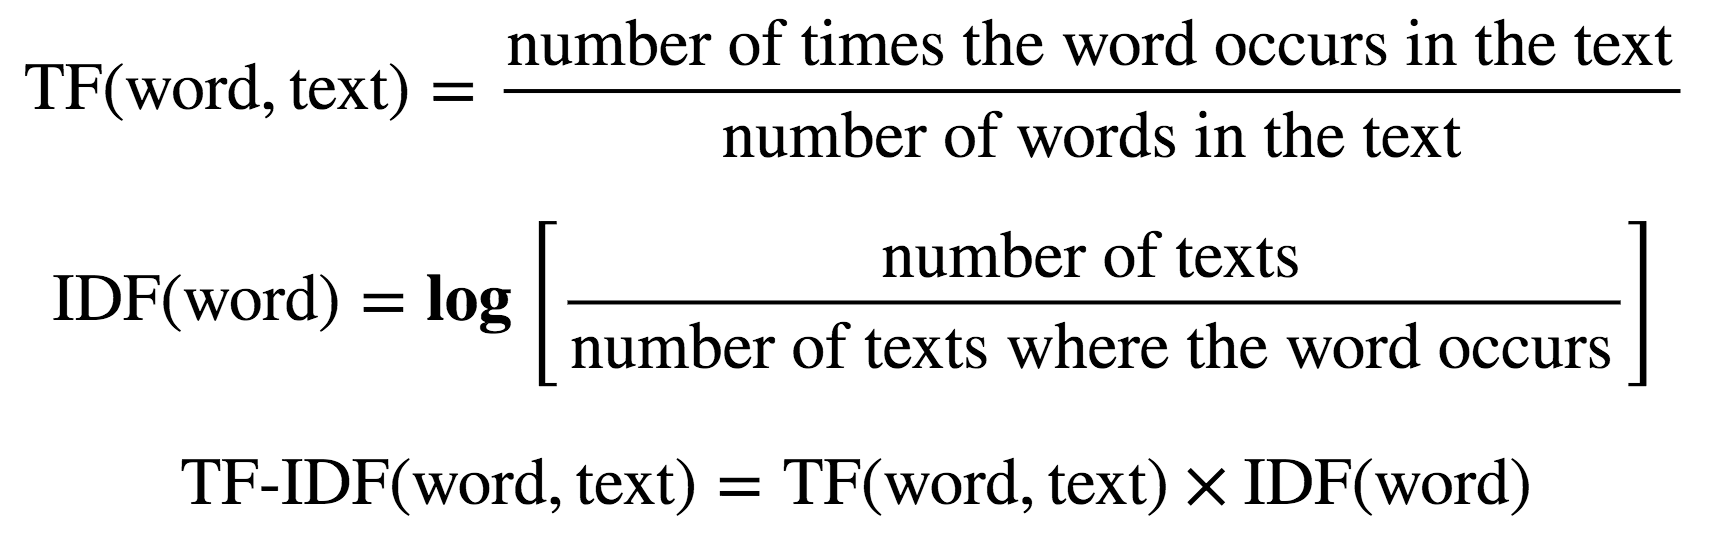

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
doc_1 = "Data is the oil of the digital economy"
doc_2 = "Data is a new oil"

data = [doc_1, doc_2]


In [13]:
tfidf = TfidfVectorizer()
result = tfidf.fit_transform(data)

In [14]:
df = pd.DataFrame(result.toarray(), columns=tfidf.get_feature_names_out())
df

,data,digital,economy,is,new,of,oil,the
0,0.243777,0.34262,0.34262,0.243777,0.000000,0.34262,0.243777,0.68524
1,0.448321,0.00000,0.00000,0.448321,0.630099,0.00000,0.448321,0.00000


# Task 1:

In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# 2. LOAD THE SENTENCES
sentences = [
    "One Cent, Two Cents, Old Cent, New Cent: All About Money (Cat in the Hat's Learning Library",
    "Inside Your Outside: All About the Human Body (Cat in the Hat's Learning Library)",
    "Oh, The Things You Can Do That Are Good for You: All About Staying Healthy (Cat in the Hat's Learning Library)",
    "On Beyond Bugs: All About Insects (Cat in the Hat's Learning Library)",
    "There's No Place Like Space: All About Our Solar System (Cat in the Hat's Learning Library)"
]

# 3. COUNT EACH WORD
vec = CountVectorizer()
X = vec.fit_transform(sentences)
count_df = pd.DataFrame(X.toarray(),
                        index=[f"Sentence {i + 1}" for i in range(len(sentences))],
                        columns=vec.get_feature_names_out())
with pd.option_context("display.max_columns", None):
    display(count_df)

,about,all,are,beyond,body,bugs,can,cat,cent,cents,do,for,good,hat,healthy,human,in,insects,inside,learning,library,like,money,new,no,oh,old,on,one,our,outside,place,solar,space,staying,system,that,the,there,things,two,you,your
Sentence 1,1,1,0,0,0,0,0,1,3,1,0,0,0,1,0,0,1,0,0,1,1,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0
Sentence 2,1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2,0,0,0,0,1
Sentence 3,1,1,1,0,0,0,1,1,0,0,1,1,1,1,1,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,2,0,1,0,2,0
Sentence 4,1,1,0,1,0,1,0,1,0,0,0,0,0,1,0,0,1,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Sentence 5,1,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,1,1,1,0,1,0,1,1,0,0,0,0


# Task 2:

In [3]:
# 1. LOAD THE SENTENCES
similarity_sentences = [
    'This is the first document.',
    'This document is the second document.',
    'And this is the third one.',
    'Is this the first document?'
]

# 2. CREATE THE COUNT VECTORS
count_vectorizer = CountVectorizer()
vector_matrix = count_vectorizer.fit_transform(similarity_sentences)
labels = [f"Sentence {i + 1}" for i in range(len(similarity_sentences))]
display(pd.DataFrame(vector_matrix.toarray(), index=labels,
                     columns=count_vectorizer.get_feature_names_out()))

,and,document,first,is,one,second,the,third,this
Sentence 1,0,1,1,1,0,0,1,0,1
Sentence 2,0,2,0,1,0,1,1,0,1
Sentence 3,1,0,0,1,1,0,1,1,1
Sentence 4,0,1,1,1,0,0,1,0,1


In [4]:
# 3. CALCULATE COSINE SIMILARITY
cosine_similarity_matrix = cosine_similarity(vector_matrix)
df_cosine = pd.DataFrame(cosine_similarity_matrix, index=labels, columns=labels)
df_cosine.round(4)

,Sentence 1,Sentence 2,Sentence 3,Sentence 4
Sentence 1,1.0000,0.7906,0.5477,1.0000
Sentence 2,0.7906,1.0000,0.4330,0.7906
Sentence 3,0.5477,0.4330,1.0000,0.5477
Sentence 4,1.0000,0.7906,0.5477,1.0000


# Task 3:

In [5]:
# 1. LOAD THE SENTENCES
tfidf_sentences = [
    'data science is one of the most important fields of science',
    'this is one of the best data science courses',
    'data scientists analyze data'
]

# 2. CALCULATE TF-IDF
tfidf = TfidfVectorizer()
result = tfidf.fit_transform(tfidf_sentences)
tfidf_df = pd.DataFrame(result.toarray(),
                        index=[f"Sentence {i + 1}" for i in range(len(tfidf_sentences))],
                        columns=tfidf.get_feature_names_out())
with pd.option_context("display.max_columns", None):
    display(tfidf_df.round(4))

,analyze,best,courses,data,fields,important,is,most,of,one,science,scientists,the,this
Sentence 1,0.0000,0.0000,0.0000,0.1895,0.3209,0.3209,0.2440,0.3209,0.4881,0.2440,0.4881,0.0000,0.2440,0.0000
Sentence 2,0.0000,0.4003,0.4003,0.2364,0.0000,0.0000,0.3044,0.0000,0.3044,0.3044,0.3044,0.0000,0.3044,0.4003
Sentence 3,0.5427,0.0000,0.0000,0.6411,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5427,0.0000,0.0000


In [6]:
# 3. DISPLAY THE MOST IMPORTANT WORDS
for sentence, scores in tfidf_df.iterrows():
    ranked = scores[scores > 0].sort_values(ascending=False)
    print(f"\n{sentence} - top 3 words:")
    print(ranked.head(3).round(4).to_string())
    top_words = scores[scores == scores.max()].index.tolist()
    print("Highest-scoring word(s):", ", ".join(top_words))


Sentence 1 - top 3 words:
science    0.4881
of         0.4881
most       0.3209
Highest-scoring word(s): of, science

Sentence 2 - top 3 words:
best       0.4003
courses    0.4003
this       0.4003
Highest-scoring word(s): best, courses, this

Sentence 3 - top 3 words:
data          0.6411
analyze       0.5427
scientists    0.5427
Highest-scoring word(s): data
